# 🌊 BinWaves North Carolina (Validation)

> **Inputs:**
> - `Kp_coefficients.nc` file saved in the `outputs/` folder, obtained with the `Propagation Notebook`
> - OPTIONAL: buoy_buoy_ID_bulk_parameters.pkl`: wave bulk parameters (Hs, Tp, Dp) stored in the `inputs/buoy_data/` folder.
>
>
> **Outputs:**
> - PLosty.
> - `Kp_coefficients.nc` file saved in the `outputs/` folder.

### BinWaves Notebooks Overview

This Jupyter Notebook is the first of three in the **BinWaves** modeling workflow, following Cagigal et al., 2024 :

1. `BinWaves_Propagation.ipynb`  
2. `BinWaves_Reconstruction.ipynb`  
3. `BinWaves_Validation.ipynb`

---

#### Before You Start

Make sure you have:

- Installed the latest version of `bluemath-tk`:  
  ```bash
  pip install bluemath-tk

- **BlueMath Toolkit Repository**:  [https://github.com/GeoOcean/BlueMath_tk.git](https://github.com/GeoOcean/BlueMath_tk.git)

Before continuing, ensure you have **created and activated a Python environment**.

*** Other Required Packages ***
- `wavespectra` 
- `cartophy`
 
---

<details>
<summary><strong>📁 BinWaves_Propagation.ipynb</strong></summary>

This notebook constructs the **library of pre-run cases** for all **monochromatic wave systems**.

##### Requirements:

- A **bathymetry** file placed in the `inputs/` folder, in the correct format.

If you don't have a specific bathymetry file for your study area, you can:

- **Download GEBCO bathymetry data** (~400 m resolution):  [https://download.gebco.net/](https://download.gebco.net/)


</details>

---

<details>
<summary><strong>📁 BinWaves_Reconstruction.ipynb</strong></summary>

This notebook reconstructs **wave conditions** using **offshore directional wave spectra**.

##### Requirements:

- Offshore wave spectrum data (e.g., **CAWCR** or **ERA5** datasets).

- **OPTIONAL 1**: Apply **satellite corrections** to the hindcast spectrum before running BinWaves using the `CalVal` tool in the BlueMath toolkit. An example is provided in the Jupyter Notebook **Satellite Correction**.

- **OPTIONAL 2**: A **Super Point Spectrum** can be also used as input to the hindcast spectrum before running BinWaves. The `SuperPoint` aggregates the energy from a number of points (Wave Spectra) surrounding the study site (Cagigal et al., 2021).  An example is provided in the Jupyter Notebook **Super Point Computation** .

</details>

---

<details open>
<summary><strong>📁 BinWaves_Validation.ipynb</strong></summary>

This notebook performs **validation** using **wave buoy data**, if available.

##### Requirements:

- Wave buoy data in a format compatible with BinWaves (if available).
- Some wave buoy data can be freely downloaded from:  
  🌊 [https://www.ndbc.noaa.gov/](https://www.ndbc.noaa.gov/)

- **NOTE:** You can use the `NDBC_buoy_data.ipynb` notebook to:
  - Download the buoy data.
  - Convert it into the appropriate format for BinWaves.

</details>

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
import os
import os.path as op

In [ ]:
cawcr_spectrum = xr.open_dataset('inputs/4469_spec_satellite_corrected.nc')
cawcr_spectrum

In [ ]:

buoys = {
    "44088": (-74.8390, 36.6120),
    "44100": (-75.5930, 36.2580),
    "44086": (-75.4210, 36.0010),
    "44056": (-75.7140, 36.2000),
    "44095": (-75.3300, 35.7500),
}


def find_site_index(kp_coeffs, target_x, target_y, tolerance=1.0):
    """
    Find the site index in kp_coeffs that matches the target coordinates.

    Parameters:
    -----------
    kp_coeffs : xarray.Dataset
        The kp coefficients dataset
    target_x : float
        Target UTM x coordinate
    target_y : float
        Target UTM y coordinate
    tolerance : float
        Tolerance for coordinate matching (in meters)

    Returns:
    --------
    int
        The site index that matches the coordinates
    """
    # Get all site coordinates
    site_x = kp_coeffs.coord_x.values
    site_y = kp_coeffs.coord_y.values

    # Calculate distances to all sites
    distances = np.sqrt((site_x - target_x) ** 2 + (site_y - target_y) ** 2)

    # Find the site with minimum distance
    site_index = np.argmin(distances)

    # Check if the closest site is within tolerance
    if distances[site_index] > tolerance:
        print(f"Warning: Closest site is {distances[site_index]:.2f} meters away")

    return site_index


def load_buoy_data(buoy_id, year=None):
    """
    Load buoy data and return both the wave data and location coordinates.

    Parameters:
    -----------
    buoy_id : str
        The buoy ID (e.g., '44100')
    year : str, optional
        The year to filter data for (default: None)

    Returns:
    --------
    tuple
        (buoy_waves, buoy_location, kp_coeffs)
    """
    # Load buoy data
    buoy_waves = pd.read_pickle(
        f"inputs/buoy_data/buoy_{buoy_id}_bulk_parameters.pkl"
    ).sort_index()
    if year:
        buoy_waves = buoy_waves.loc[year]
    buoy_waves = buoy_waves.dropna(subset=["Hs_Buoy", "Tp_Buoy", "Dir_Buoy"])

    # Get buoy location (both UTM and WGS84)
    buoy_location = buoys[buoy_id]

    # Load kp coefficients
    kp_coeffs = xr.open_dataset("outputs/kp_coefficients.nc")

    # Find the correct site index
    site_index = find_site_index(kp_coeffs, buoy_location[0], buoy_location[1])

    # Select the correct site
    kp_coeffs = kp_coeffs.isel(site=[site_index])

    return buoy_waves, buoy_location, kp_coeffs, site_index


# Example usage:
buoy_id = "41110"  # Change this to use different buoys
buoy_waves, buoy_location, kp_coeffs , site_index= load_buoy_data(buoy_id)

# Print the coordinates for verification
print(f"Buoy {buoy_id} coordinates:")
print(f"WGS84: {buoy_location[0]}, {buoy_location[1]}")
print(f"\nSelected kp_coeffs site coordinates:")
print(f"{kp_coeffs.coord_x.values}, {kp_coeffs.coord_y.values}")
print(f"Site index: {site_index}")

Buoy 41110 coordinates:
WGS84: -77.715, 34.142

Selected kp_coeffs site coordinates:
[-77.715], [34.142]
Site index: 602


In [ ]:
from utils.operations import transform_Offshore_spectrum

model_parameters = pd.read_csv("CASES/swan_cases.csv").to_dict(orient="list")

# Load interest spectra
offshore_spectra, offshore_spectra_case = transform_Offshore_spectrum(
    CAWCR_spectrum=cawcr_spectrum,
    subset_parameters=model_parameters,
    available_case_num=kp_coeffs.case_num.values,
    fix_direction=True, # True if efth is already in degrees(no radians) and cawcr direction for wavespectra  already corrected (from -> to)'
)
offshore_spectra_case

<xarray.DataArray 'efth' (case_num: 696, time: 405963)> Size: 2GB
array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 3.98567694e-08, 1.09282849e-05, ...,
        0.00000000e+00, 4.90667796e-06, 5.90251063e-06],
       [0.00000000e+00, 8.92564849e-08, 6.20078269e-06, ...,
        0.00000000e+00, 3.49528166e-06, 4.07282373e-06],
       [0.00000000e+00, 4.97343152e-06, 1.86456598e-06, ...,
        0.00000000e+00, 2.38413348e-06, 0.00000000e+00]],
      shape=(696, 405963))
Coordinates:
  * case_num  (case_num) int64 6kB 0 1 2 3 4 5 6 ... 689 690 691 692 693 694 695
  * time      (time) datetime64[ns] 3MB 1979-01-01 ... 2025-04-01
    station   int64 8B 4469

In [5]:

from bluemath_tk.waves.binwaves import reconstruc_spectra

# Remove duplicates from offshore_spectra_case
_, unique_idx_offshore_case = np.unique(offshore_spectra_case.time, return_index=True)
offshore_spectra_case = offshore_spectra_case.isel(time=unique_idx_offshore_case)

# Remove duplicates from offshore_spectra_case
_, unique_idx_offshore = np.unique(offshore_spectra.time, return_index=True)
offshore_spectra= offshore_spectra.isel(time=unique_idx_offshore)

# Make sure buoy_waves has unique indices
buoy_waves = buoy_waves[~buoy_waves.index.duplicated(keep="first")]

reconstructed_onshore_spectra = reconstruc_spectra(
    offshore_spectra=offshore_spectra_case.sel(time=buoy_waves.index, method="nearest"),
    kp_coeffs=kp_coeffs,
    num_workers=15,
)
reconstructed_onshore_spectra

/home/grupos/geocean/montanoj/miniforge3/envs/bluemath-fork/lib/python3.11/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 722.91 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


<xarray.Dataset> Size: 757MB
Dimensions:  (site: 1, freq: 29, dir: 24, time: 135817)
Coordinates:
  * site     (site) int64 8B 603
  * freq     (freq) float64 232B 0.035 0.0385 0.0423 ... 0.4171 0.4589 0.5047
  * dir      (dir) float64 192B 3.928 18.93 33.93 48.93 ... 318.9 333.9 348.9
    lat      float64 8B 0.0
    lon      float64 8B 0.0
    coord_x  (site) float64 8B -77.72
    coord_y  (site) float64 8B 34.14
  * time     (time) datetime64[ns] 1MB 2008-05-07T20:00:00.000013440 ... 2024...
    station  int64 8B 4469
Data variables:
    kps      (time, site, freq, dir) float64 756MB 0.0 0.0 0.0 ... 0.0 0.0 0.0

/home/grupos/geocean/montanoj/miniforge3/envs/bluemath-fork/lib/python3.11/site-packages/xarray/plot/dataarray_plot.py:512: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  primitive = ax.plot(xplt_val, yplt_val, *args, **kwargs)
/home/grupos/geocean/montanoj/miniforge3/envs/bluemath-fork/lib/python3.11/site-packages/xarray/plot/dataarray_plot.py:512: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  primitive = ax.plot(xplt_val, yplt_val, *args, **kwargs)


Time series plot saved as: outputs/Figures/timeseries_Wave Validation 41110.png
Scatter plot saved as: outputs/Figures/scatter_Wave Validation 41110.png


(<Figure size 2000x1000 with 3 Axes>,
 array([<Axes: xlabel='time', ylabel='Hs [m]'>,
        <Axes: xlabel='time', ylabel='T [s] - tp'>,
        <Axes: ylabel='Dir [°] - dm'>], dtype=object),
 <Figure size 1500x500 with 3 Axes>,
 array([<Axes: xlabel='Hs - Buoy [m]', ylabel='Hs - BinWaves [m]'>,
        <Axes: xlabel='Tp - Buoy [s]', ylabel='Tp - BinWaves [s]'>,
        <Axes: xlabel='Dir - Buoy [°]', ylabel='Dir - BinWaves [°]'>],
       dtype=object))

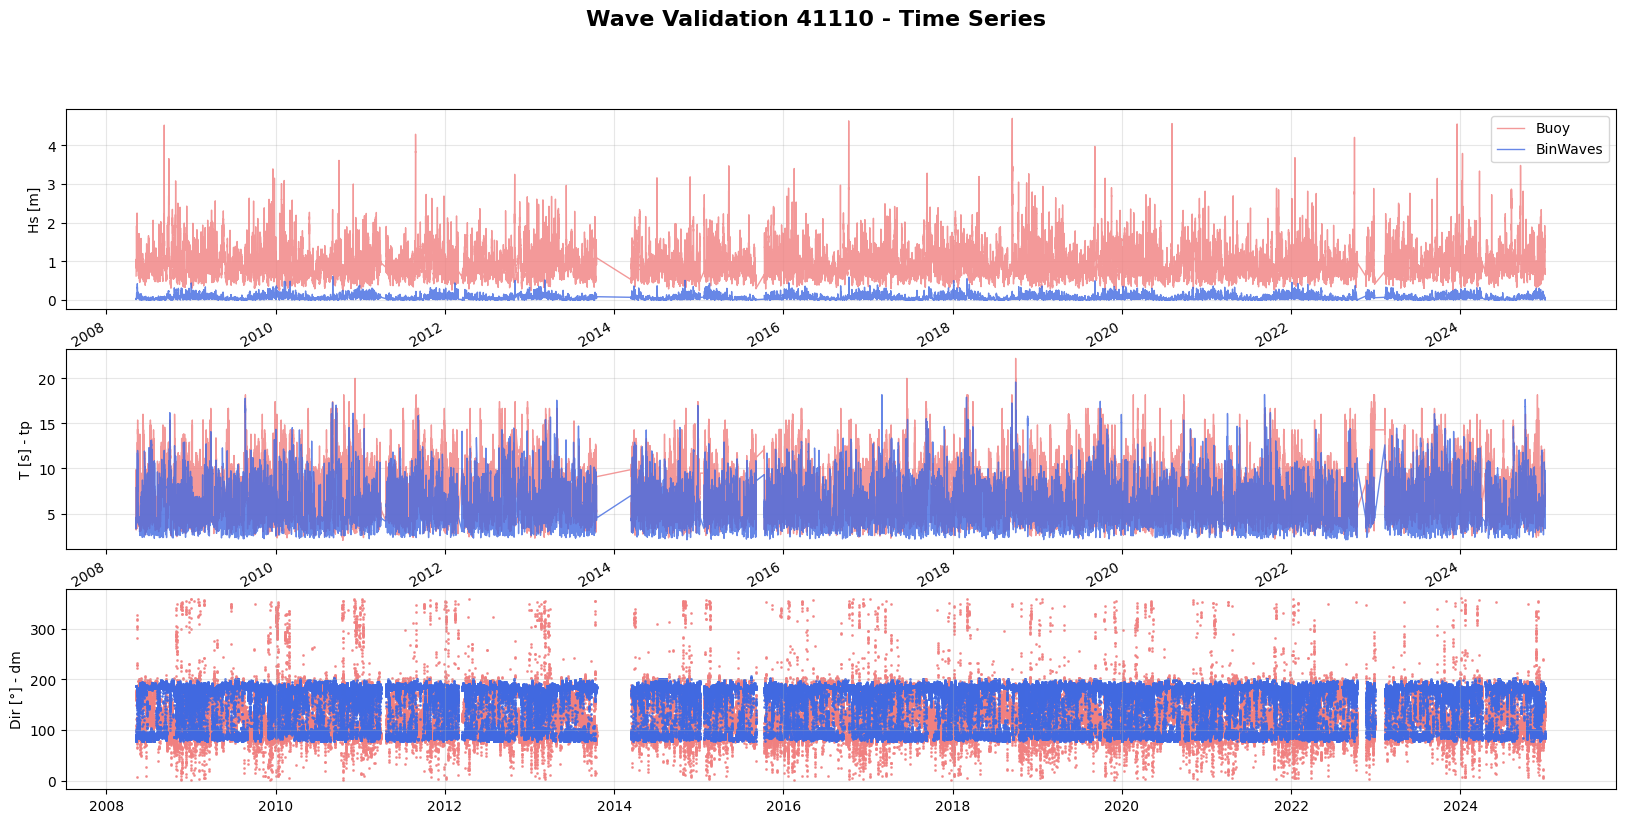

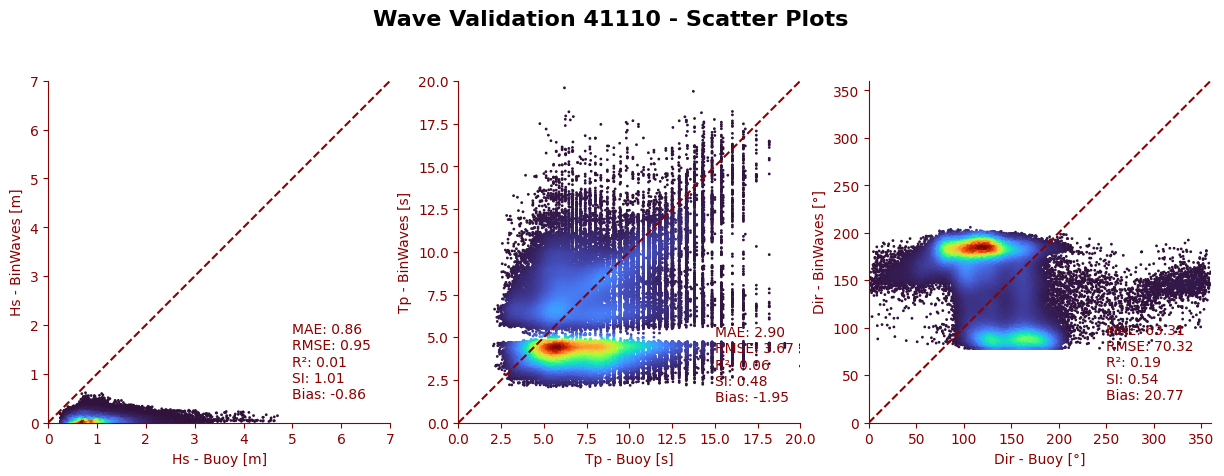

In [6]:
from utils.plotting import plot_wave_series

plot_wave_series(
    buoy_data=buoy_waves,
    binwaves_data=reconstructed_onshore_spectra.sel(
        time=buoy_waves.index, method="nearest"
    )
    .rename({"kps": "efth"})
    .squeeze()
    .spec,
    offshore_data=offshore_spectra.sel(time=buoy_waves.index, method="nearest").spec,
    times=buoy_waves.index.values,
    save_plots=True,
    save_path="outputs/Figures/",
    title_prefix="Wave Validation "+ buoy_id,
)

In [7]:
def save_validation_csv_with_interpolation(
    buoy_data: pd.DataFrame,
    binwaves_hs: np.ndarray,
    binwaves_tp: np.ndarray,
    binwaves_dpm: np.ndarray,
    buoy_id: str,
    save_path: str = "outputs",
    filename_prefix: str = "buoy",
    target_resolution: str = "1D",
):
    """
    Save validation data to CSV files, creating hourly data and interpolating to target resolution.
    
    Parameters:
    -----------
    buoy_data : pd.DataFrame
        Buoy wave data with columns: Hs_Buoy, Tp_Buoy, Dir_Buoy
    binwaves_hs : np.ndarray
        BinWaves significant wave height time series
    binwaves_tp : np.ndarray
        BinWaves peak period time series
    binwaves_dpm : np.ndarray
        BinWaves mean direction time series
    buoy_id : str
        Buoy ID for filename
    save_path : str, optional
        Directory to save the CSV files (default: "outputs")
    filename_prefix : str, optional
        Prefix for the filename (default: "buoy")
    target_resolution : str, optional
        Target resolution for interpolation. Options: "3h", "6h", "1D"/"daily" (default: "1D")
    
    Returns:
    --------
    tuple
        (hourly_filepath, interpolated_filepath) - Paths to both saved CSV files
    """
    import os
    import numpy as np
    from datetime import timedelta
    import pandas as pd

    print(f"Creating validation data with interpolation to {target_resolution}...")

    # Create directory if it doesn't exist
    os.makedirs(save_path, exist_ok=True)

    # Round the datetime index to the nearest hour to align with the hourly grid
    buoy_data = buoy_data.copy()
    buoy_data.index = pd.to_datetime(buoy_data.index).round('1H')
    # Aggregate duplicate timestamps by taking the mean
    buoy_data = buoy_data.groupby(buoy_data.index).mean()

    # Create hourly DataFrame (original data)
    hourly_df = pd.DataFrame({
        'datetime': buoy_data.index,
        'Hs_Buoy': buoy_data['Hs_Buoy'].values,
        'Tp_Buoy': buoy_data['Tp_Buoy'].values,
        'Dir_Buoy': buoy_data['Dir_Buoy'].values,
        'Hs_BinWaves': binwaves_hs,
        'Tp_BinWaves': binwaves_tp,
        'Dir_BinWaves': binwaves_dpm,
    })
    hourly_df.set_index('datetime', inplace=True)

    # Create regular hourly time index for interpolation
    start_time = hourly_df.index.min()
    end_time = hourly_df.index.max()

    # Create hourly time index
    hourly_times = pd.date_range(start=start_time, end=end_time, freq='1H')

    # Reindex to hourly and interpolate, but only for small gaps (e.g., up to 3 hours)
    hourly_df_interpolated = hourly_df.reindex(hourly_times).interpolate(
        method='linear', limit=3, limit_direction='both', limit_area='inside'
    )

    # Create target resolution time index
    if target_resolution == "3h":
        target_times = pd.date_range(start=start_time, end=end_time, freq='3H')
    elif target_resolution == "6h":
        target_times = pd.date_range(start=start_time, end=end_time, freq='6H')
    elif target_resolution == "1D" or target_resolution == "daily":
        target_times = pd.date_range(start=start_time, end=end_time, freq='1D')
    else:
        # Default to 3h if not specified
        target_times = pd.date_range(start=start_time, end=end_time, freq='3H')

    # Interpolate to target resolution
    target_df = hourly_df_interpolated.reindex(target_times).interpolate(method='linear')

    # Save hourly data
    hourly_filename = f"{filename_prefix}_{buoy_id}_1h.csv"
    hourly_filepath = os.path.join(save_path, hourly_filename)
    hourly_df_interpolated.to_csv(hourly_filepath)

    # Save target resolution data
    target_filename = f"{filename_prefix}_{buoy_id}_{target_resolution}.csv"
    target_filepath = os.path.join(save_path, target_filename)
    target_df.to_csv(target_filepath)

    print(f"Hourly data saved as: {hourly_filepath}")
    print(f"Hourly data shape: {hourly_df_interpolated.shape}")
    print(f"Hourly time range: {hourly_df_interpolated.index.min()} to {hourly_df_interpolated.index.max()}")

    print(f"\n{target_resolution} data saved as: {target_filepath}")
    print(f"{target_resolution} data shape: {target_df.shape}")
    print(f"{target_resolution} time range: {target_df.index.min()} to {target_df.index.max()}")

    return hourly_filepath, target_filepath

In [8]:
# 1. Round and group the buoy index
buoy_waves = buoy_waves.copy()
buoy_waves.index = pd.to_datetime(buoy_waves.index).round('1H')
buoy_waves = buoy_waves.groupby(buoy_waves.index).mean()

# 2. Use the new index to extract binwaves data
binwaves_spec = reconstructed_onshore_spectra.sel(
    time=buoy_waves.index, method="nearest"
).rename({"kps": "efth"}).squeeze().spec

binwaves_hs = binwaves_spec.hs().values
binwaves_tp = binwaves_spec.tp().values
binwaves_dpm = binwaves_spec.dpm().values

# 3. Now call the function
hourly_file, three_hourly_file = save_validation_csv_with_interpolation(
    buoy_data=buoy_waves,
    binwaves_hs=binwaves_hs,
    binwaves_tp=binwaves_tp,
    binwaves_dpm=binwaves_dpm,
    buoy_id=buoy_id,
    save_path="outputs/time_series/",
    filename_prefix="buoy_validation",
    target_resolution="1d"
)

/tmp/ipykernel_1536045/3114898764.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  buoy_waves.index = pd.to_datetime(buoy_waves.index).round('1H')


Creating validation data with interpolation to 1d...


/tmp/ipykernel_1536045/2721154551.py:50: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  buoy_data.index = pd.to_datetime(buoy_data.index).round('1H')
/tmp/ipykernel_1536045/2721154551.py:71: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_times = pd.date_range(start=start_time, end=end_time, freq='1H')
/tmp/ipykernel_1536045/2721154551.py:87: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  target_times = pd.date_range(start=start_time, end=end_time, freq='3H')


Hourly data saved as: outputs/time_series/buoy_validation_41110_1h.csv
Hourly data shape: (145972, 6)
Hourly time range: 2008-05-07 20:00:00 to 2024-12-31 23:00:00

1d data saved as: outputs/time_series/buoy_validation_41110_1d.csv
1d data shape: (48658, 6)
1d time range: 2008-05-07 20:00:00 to 2024-12-31 23:00:00


In [9]:
# Check for NaN values in the data before plotting
print("Checking for NaN values in the data:")
print(f"Buoy Hs NaN count: {buoy_waves['Hs_Buoy'].isna().sum()}")
print(f"Buoy Tp NaN count: {buoy_waves['Tp_Buoy'].isna().sum()}")
print(f"Buoy Dir NaN count: {buoy_waves['Dir_Buoy'].isna().sum()}")

# Check binwaves data
binwaves_spec_check = reconstructed_onshore_spectra.sel(
    time=buoy_waves.index, method="nearest"
).rename({"kps": "efth"}).squeeze().spec

binwaves_hs_check = binwaves_spec_check.hs().values
binwaves_tp_check = binwaves_spec_check.tp().values
binwaves_dpm_check = binwaves_spec_check.dpm().values

print(f"BinWaves Hs NaN count: {np.isnan(binwaves_hs_check).sum()}")
print(f"BinWaves Tp NaN count: {np.isnan(binwaves_tp_check).sum()}")
print(f"BinWaves Dir NaN count: {np.isnan(binwaves_dpm_check).sum()}")

print(f"\nData shapes:")
print(f"Buoy data: {buoy_waves.shape}")
print(f"BinWaves Hs: {binwaves_hs_check.shape}")
print(f"BinWaves Tp: {binwaves_tp_check.shape}")
print(f"BinWaves Dir: {binwaves_dpm_check.shape}")


Checking for NaN values in the data:
Buoy Hs NaN count: 0
Buoy Tp NaN count: 0
Buoy Dir NaN count: 0
BinWaves Hs NaN count: 0
BinWaves Tp NaN count: 0
BinWaves Dir NaN count: 0

Data shapes:
Buoy data: (135817, 5)
BinWaves Hs: (135817,)
BinWaves Tp: (135817,)
BinWaves Dir: (135817,)
